# Regulatory Network Analysis of Fetal Stem Cells using scPRINT 

* **Author**: Anna Maguza 
* **Location**: CellZome, GSK company
* **Creation date**: 20.08.2025
* **Last modified date**: 04.09.2025

In [1]:
from huggingface_hub import hf_hub_download

from scprint import scPrint
from scdataloader import Preprocessor, utils
from scdataloader.preprocess import additional_preprocess
from scdataloader.utils import load_genes
from scprint.tasks import GNInfer
from grnndata import utils as grnutils
from grnndata import read_h5ad

import lamindb as ln
import scanpy as sc
import numpy as np
from pybiomart import Dataset
from matplotlib import pyplot as plt
import pandas as pd
import json
from anndata.utils import make_index_unique

import gseapy as gp
from gseapy import dotplot
from pyvis import network as pnx
import networkx as nx
import scipy.sparse

%load_ext autoreload
%autoreload 2 

import torch
torch.set_float32_matmul_precision('medium')

import os
import ssl
import urllib3

No module named 'triton'
FlashAttention is not installed, not using it..


/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


→ connected lamindb: anonymous/test


## Preprocessing

In [2]:
adata = sc.read_h5ad("gut_data/gut_hs_full_annotated_AM_06032025_140458_raw.h5ad")
adata

AnnData object with n_obs × n_vars = 365542 × 43704
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_pro

In [3]:
fetal_mask = ["second trimester", "first trimester"]
adata = adata[adata.obs["age_group"].isin(fetal_mask)]

In [4]:
adata.obs["age_group"].value_counts()

age_group
second trimester    169380
first trimester     148150
Name: count, dtype: int64

In [5]:
adata.obs

,cell_index,Source Name,ENA_SAMPLE,BioSD_SAMPLE,organism,disease,organism_part,cell_type,growth_condition,developmental_stage,Material Type,Protocol REF,sample_id,LIBRARY_LAYOUT,cdna_read_size,cell_barcode_size,end_bias,library_construction,sample_barcode_size,umi_barcode_offset,umi_barcode_size,Performer,Assay Name,ENA_EXPERIMENT,ENA_RUN,time,time_unit,n_genes,doublet_scores,predicted_doublets,n_counts,log1p_n_counts,log1p_n_genes,percent_mito,n_counts_mito,percent_ribo,n_counts_ribo,percent_hb,n_counts_hb,percent_top50,cell_passed_qc,qc_cluster,cluster_passed_qc,consensus_fraction,consensus_passed_qc,total_counts,n_genes_by_counts,percent_chrY,XIST-counts,XIST-percentage,sex,S_score,G2M_score,Cell_cycle_phase,Study_name,ArrayExpress_ID,library_preparation_protocol,full_age,age_group,immunophenotype,metadata_cluster,barcode,category,Integrated_05,age,gestational_age,donor_id,passage,batch,sampling_site,celltype,library_construnction_and_layout,cell_states,cellstates_scANVI,confidence_score,gut_region,cell_state
cell_index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AAACGGGTCGAATCCA-1-4918STDY7421299_ERR4010667,AAACGGGTCGAATCCA-1-4918STDY7421299_ERR4010667,BRC2043_CO_pos_cells,ERS4414933,SAMEA6655464,Homo sapiens,normal,colon,intestinal epithelial cell,primary tissue,10th week post-fertilization human stage,cell,P-MTAB-95162,BRC2043_CO_pos_cells,PAIRED,98,16,3 prime tag,10xV2,8,16,10,Wellcome Sanger Institute,BRC2043_CO_pos_cells,ERX4012067,ERR4010667,N/A,week,2373,0.186747,False,9640,9.173780,7.772332,1.649378,159.0,35.041494,3378.0,0.0,0.0,36.960581,True,8,True,0.6,True,9640,2373,0.103734,0,0.000000,male,-0.014920,-0.278880,G1,Elementaite_2021,E-MTAB-8901,10xV2 3 prime tag,12.2 week,second trimester,EPCAM positive,3,AAACGGGTCGAATCCA,Epithelial,Colonocyte,,12.2,BRC2043,N/A,4918STDY7421299,unknown,Epithelial,10xV2_PAIRED,Stem cells,Stem cells,0.318226,large intestine,NaN
AAAGCAACAAACCTAC-1-4918STDY7421299_ERR4010667,AAAGCAACAAACCTAC-1-4918STDY7421299_ERR4010667,BRC2043_CO_pos_cells,ERS4414933,SAMEA6655464,Homo sapiens,normal,colon,intestinal epithelial cell,primary tissue,10th week post-fertilization human stage,cell,P-MTAB-95162,BRC2043_CO_pos_cells,PAIRED,98,16,3 prime tag,10xV2,8,16,10,Wellcome Sanger Institute,BRC2043_CO_pos_cells,ERX4012067,ERR4010667,N/A,week,5863,0.163934,False,61106,11.020382,8.676587,4.670572,2854.0,35.659346,21790.0,0.0,0.0,39.591857,True,8,True,1.0,True,61106,5863,0.132557,0,0.000000,male,-0.254676,-1.023004,G1,Elementaite_2021,E-MTAB-8901,10xV2 3 prime tag,12.2 week,second trimester,EPCAM positive,3,AAAGCAACAAACCTAC,Epithelial,Colonocyte,,12.2,BRC2043,N/A,4918STDY7421299,unknown,Epithelial,10xV2_PAIRED,Colonocyte,Colonocyte,0.986588,large intestine,NaN
AAATGCCAGGGATCTG-1-4918STDY7421299_ERR4010667,AAATGCCAGGGATCTG-1-4918STDY7421299_ERR4010667,BRC2043_CO_pos_cells,ERS4414933,SAMEA6655464,Homo sapiens,normal,colon,intestinal epithelial cell,primary tissue,10th week post-fertilization human stage,cell,P-MTAB-95162,BRC2043_CO_pos_cells,PAIRED,98,16,3 prime tag,10xV2,8,16,10,Wellcome Sanger Institute,BRC2043_CO_pos_cells,ERX4012067,ERR4010667,N/A,week,454,0.250000,False,965,6.873164,6.120297,8.082902,78.0,41.347150,399.0,0.0,0.0,47.150259,True,15,True,0.8,True,965,454,0.000000,0,0.000000,male,-0.174000,0.495131,G2M,Elementaite_2021,E-MTAB-8901,10xV2 3 prime tag,12.2 week,second trimester,EPCAM positive,3,AAATGCCAGGGATCTG,Unknown,Unknown,,12.2,BRC2043,N/A,4918STDY7421299,unknown,Epithelial,10xV2_PAIRED,Enterocyte,Enterocyte,0.694930,large intestine,NaN
AACCGCGTCATTTGGG-1-4918STDY7421299_ERR4010667,AACCGCGTCATTTGGG-1-4918STDY7421299_ERR4010667,BRC2043_CO_pos_cells,ERS4414933,SAMEA6655464,Homo sapiens,normal,colon,intestinal epithelial cell,primary tissue,10th week post-fertilization human stage,cell,P-MTAB-95162,BRC2043_CO_pos_cells,PAIRED,98,16,3 prime tag,10xV2,8,16,10,Wellcome Sanger Institute,BRC2043_CO_pos_cells,ERX4012067,ERR4010667,N/A,week,2538,0.186747,False,10879

### Load ontology mapping file

In [6]:
with open('ontology_terms.json', 'r') as f:
    ontology_data = json.load(f)

cell_type_mapping = {item['cell_annotation']: item['ontology_term'] 
                     for item in ontology_data['ontology_terms']}
tissue_mapping = {item['tissue']: item['ontology_term'] 
                  for item in ontology_data['tissue_mapping']}
sex_mapping = ontology_data['sex_mapping']
age_group_mapping = ontology_data['age_group_mapping']
assay_mapping = ontology_data['assay_mapping']

In [7]:
adata.obs['organism'] = 'Homo sapiens'
adata.obs['organism_ontology_term_id'] = 'NCBITaxon:9606'

In [8]:
# Map cell_states to cell_type_ontology_term_id
adata.obs['cell_type_ontology_term_id'] = 'unknown'
for cell_type in adata.obs['cell_states'].unique():
    if cell_type in cell_type_mapping:
        ontology_id = cell_type_mapping[cell_type]
        mask = adata.obs['cell_states'] == cell_type
        adata.obs.loc[mask, 'cell_type_ontology_term_id'] = ontology_id
    else:
        print(f"No mapping found for '{cell_type}', keeping as 'unknown'")

In [9]:
# Map age_group to development_stage_ontology_term_id
adata.obs['development_stage_ontology_term_id'] = adata.obs['age_group'].map(age_group_mapping)

In [10]:
# Map gut_region to tissue_ontology_term_id 
if 'gut_region' in adata.obs.columns:
    adata.obs['tissue_ontology_term_id'] = adata.obs['gut_region'].map(tissue_mapping)
else:
    adata.obs['tissue_ontology_term_id'] = 'unknown'


In [11]:
# Map sex to sex_ontology_term_id 
if 'sex' in adata.obs.columns:
    # Convert to string to handle categorical issues
    adata.obs['sex_normalized'] = adata.obs['sex'].astype(str).str.lower()
    adata.obs['sex_ontology_term_id'] = adata.obs['sex_normalized'].map(sex_mapping).fillna('unknown')
    adata.obs.drop('sex_normalized', axis=1, inplace=True)
else:
    adata.obs['sex_ontology_term_id'] = 'unknown'

In [12]:
# Map library_preparation_protocol to assay_ontology_term_id
protocol_str = adata.obs['library_preparation_protocol'].astype(str)
adata.obs['assay_ontology_term_id'] = protocol_str.map(assay_mapping).fillna('EFO:0008913')

In [13]:
adata.obs['self_reported_ethnicity_ontology_term_id'] = 'unknown'
adata.obs['disease_ontology_term_id'] = 'PATO:0000461'  # normal

In [14]:
required_cols = ['organism_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 
                'assay_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id',
                'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id']
missing_cols = [col for col in required_cols if col not in adata.obs.columns]
print(f"WARNING: Missing required columns: {missing_cols}")


In [15]:
adata.var["gene_symbol"] = adata.var.index.copy()

In [16]:
adata.var

,gene_symbol
WASH7P,WASH7P
ENSG00000238009,ENSG00000238009
CICP27,CICP27
ENSG00000268903,ENSG00000268903
ENSG00000269981,ENSG00000269981
...,...
ENSG00000277836,ENSG00000277836
ENSG00000278633,ENSG00000278633
ENSG00000276017,ENSG00000276017
ENSG00000278817,ENSG00000278817


In [17]:
dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

In [18]:
biomart_results = dataset.query(attributes=['ensembl_gene_id', 'external_gene_name'])

In [19]:
biomart_results

,Gene stable ID,Gene name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1
...,...,...
86359,ENSG00000197989,SNHG12
86360,ENSG00000229388,TAF12-DT
86361,ENSG00000289291,NaN
86362,ENSG00000274978,RNU11


In [20]:
adata.var

,gene_symbol
WASH7P,WASH7P
ENSG00000238009,ENSG00000238009
CICP27,CICP27
ENSG00000268903,ENSG00000268903
ENSG00000269981,ENSG00000269981
...,...
ENSG00000277836,ENSG00000277836
ENSG00000278633,ENSG00000278633
ENSG00000276017,ENSG00000276017
ENSG00000278817,ENSG00000278817


In [21]:
# Create a mapping dictionary from biomart_results
gene_id_map = biomart_results.set_index('Gene name')['Gene stable ID'].to_dict()

# Add ensembl gene IDs to adata.var
adata.var['gene_id-query'] = adata.var['gene_symbol'].map(gene_id_map)

# Fill missing values with the corresponding index values
adata.var['gene_id-query'] = adata.var['gene_id-query'].fillna(adata.var.index.to_series())

In [22]:
adata.var.index = adata.var['gene_id-query'].copy()

In [23]:
# Check for duplicates in var index
duplicates = adata.var.index.duplicated()
duplicates

array([False, False, False, ..., False, False, False])

In [24]:
adata.var

,gene_symbol,gene_id-query
gene_id-query,,
ENSG00000310526,WASH7P,ENSG00000310526
ENSG00000238009,ENSG00000238009,ENSG00000238009
ENSG00000233750,CICP27,ENSG00000233750
ENSG00000268903,ENSG00000268903,ENSG00000268903
ENSG00000269981,ENSG00000269981,ENSG00000269981
...,...,...
ENSG00000277836,ENSG00000277836,ENSG00000277836
ENSG00000278633,ENSG00000278633,ENSG00000278633
ENSG00000276017,ENSG00000276017,ENSG00000276017


In [25]:
if adata.var.index.duplicated().any():
    adata = adata[:, ~adata.var.index.duplicated(keep='first')]

### Preprocessor module
scPRINT converts the gene expression of a cell to an embedding by summing three representations or tokens: its id, expression, and genomic location scdataloader. The Preprocessor module specifically handles:

Gene ID Encoding: scPRINT encodes the gene IDs using protein embeddings. This gene representation is made using the ESM2 amino-acid embedding of its most common protein product.   
Expression Embedding: The gene's expression is tokenized via a multi-layer perceptron (MLP) using log-normalized counts. This MLP lets the model learn a metric behind gene expression.   
Positional Encoding: We help the model know that genes with similar locations tend to be regulated by identical DNA regions, using the positional encoding of their location in the genome.   

The preprocessor makes sure that the fields are all here, the genes are in the right format, the raw counts are used.

In [26]:
preprocessor = Preprocessor(
    do_postp=True, # takes too much RAM in collab to do PCA
    # additional_postprocess=additional_postprocess,
    additional_preprocess=additional_preprocess,
    force_preprocess=True,
)

In [27]:
adata.var.index = adata.var["gene_id-query"].astype(str).copy()

In [28]:
adata = preprocessor(adata)

Dropping layers:  KeysView(Layers with keys: )
checking raw counts
removed 0 non primary cells, 317530 renamining
filtered out 20 cells, 317510 renamining
Removed 1376 genes not known to the ontology
Removed 0 duplicate genes
Added 28299 genes in the ontology but not present in the dataset
validating


/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/scdataloader/preprocess.py:287: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata, organism=adata.obs.organism_ontology_term_id[0], need_all=False


starting QC
Seeing 97056 outliers (30.57% of total dataset):
normalize
starting PCA
done
AnnData object with n_obs × n_vars = 317510 × 70611
    obs: 'cell_index', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', '

In [30]:
file = ln.Artifact.from_anndata(adata, description="test anndata")
file.save()
col = ln.Collection(file, name="test")
col.save()

! no run & transform got linked, call `ln.track()` & re-run
! no run & transform got linked, call `ln.track()` & re-run
! run input wasn't tracked, call `ln.track()` and re-run


/var/folders/8j/syfvxwvd4lggpmnnpd_r8jkr0000gp/T/ipykernel_14707/1650442001.py:3: FutureWarning: argument `name` will be removed, please pass test to `key` instead
  col = ln.Collection(file, name="test")


Collection(uid='5cdq4QgWwoGfkcUR0000', is_latest=True, key='test', hash='GwteGngkbL_NBDXTFv8TgQ', created_by_id=1, space_id=1, created_at=2025-09-08 07:41:32 UTC)

### Loading the model

In [31]:
# Disable SSL warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Set environment variables to disable SSL verification
os.environ['PYTHONHTTPSVERIFY'] = '0'
os.environ['CURL_CA_BUNDLE'] = ''
os.environ['REQUESTS_CA_BUNDLE'] = ''
os.environ['SSL_VERIFY'] = 'false'

# Configure SSL context
ssl._create_default_https_context = ssl._create_unverified_context

# Configure requests to not verify SSL
import requests.packages.urllib3.util.ssl_
requests.packages.urllib3.util.ssl_.DEFAULT_CIPHERS = 'ALL'

# Monkey patch requests to disable SSL verification
original_request = requests.Session.request
def patched_request(self, method, url, **kwargs):
    kwargs['verify'] = False
    return original_request(self, method, url, **kwargs)
requests.Session.request = patched_request

# Now download the model
model_checkpoint_file = hf_hub_download(
    repo_id="jkobject/scPRINT", 
    filename="v2-medium.ckpt"
)

In [ ]:
model_checkpoint_file 

In [33]:
# make sure that you check if you have a GPU with flashattention or not (see README)
try:
    m = torch.load(model_checkpoint_file)
# if not use this instead since the model weights are by default mapped to GPU types
except RuntimeError: 
    m = torch.load(model_checkpoint_file, map_location=torch.device('cpu'))

In [34]:
# again here by default the model was trained with flash attention, so if you do not have a GPU you will need to replace the attention mechanism with regular attention 
transformer = "flash" if torch.cuda.is_available() else "normal"

In [35]:
# both are for compatibility issues with different versions of the pretrained model, so we need to load it with the correct transformer
if "prenorm" in m['hyper_parameters']:
    m['hyper_parameters'].pop("prenorm")
    torch.save(m, model_checkpoint_file)
if "label_counts" in m['hyper_parameters']:
    # you need to set precpt_gene_emb=None otherwise the model will look for its precomputed gene embeddings files although they were already converted into model weights, so you don't need this file for a pretrained model
    model = scPrint.load_from_checkpoint(model_checkpoint_file, precpt_gene_emb=None, classes=m['hyper_parameters']['label_counts'], transformer=transformer)
else:
    model = scPrint.load_from_checkpoint(model_checkpoint_file, precpt_gene_emb=None, transformer=transformer)

RuntimeError caught: scPrint is not attached to a `Trainer`.


In [36]:
# this might happen if you have a model that was trained with a different set of genes than the one you are using in the ontology (e.g. newer ontologies), While having genes in the onlogy not in the model is fine. the opposite is not, so we need to remove the genes that are in the model but not in the ontology
missing = set(model.genes) - set(load_genes(model.organisms).index)
if len(missing) > 0:
    print(
        "Warning: some genes missmatch exist between model and ontology: solving...",
    )

In [37]:
# again if not on GPU you need to convert the model to float64
if not torch.cuda.is_available():
    model = model.to(torch.float32)
    
# you can perform your inference on float16 if you have a GPU, otherwise use float64
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# the models are often loaded with some parts still displayed as "cuda" and some as "cpu", so we need to make sure that the model is fully on the right device 
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

## Download data and filter

In [38]:
#sc.pp.filter_genes(adata, min_cells=1)

In [39]:
adata.layers["counts"] = adata.X.copy()

In [40]:
sc.pp.highly_variable_genes(adata, 
                            n_top_genes=3000, 
                            batch_key="sample_id",
                            layer="counts",
                            flavor="seurat_v3",
                            subset=False,  # Don't subset - just mark highly variable genes
                            span=1)

# Let's see how many highly variable genes we have
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")
print(f"Total genes: {adata.n_vars}")

Number of highly variable genes: 3000
Total genes: 70611


In [41]:
# Keep the filtered dataset for GRN inference
print(f"Filtered dataset shape: {adata.shape}")
print(f"Number of highly variable genes: {adata.n_vars}")

Filtered dataset shape: (317510, 70611)
Number of highly variable genes: 70611


### Gene network inference

Finally we will use scPRINT to infer gene networks on another cell of interest, the fibroblasts, in both normal and BPH conditions.

**• "most var within"**:  
    ◦ Purpose: This method identifies genes that show the highest variability or dispersion in their expression levels within a specified cell type or a homogeneous subset of your data. It aims to capture the intrinsic heterogeneity or dynamic range of gene expression within a particular biological population.
        ▪ The code first subsets the AnnData object (adata) to only include cells of the cell_type specified (if provided) into subadata.   
        ▪ It then applies sc.pp.highly_variable_genes(subadata, flavor="seurat_v3", n_top_genes=self.num_genes). This function is designed to identify genes that are highly variable within the input data subset (subadata). The seurat_v3 flavor is a common method in single-cell analysis for this purpose.   
        ▪ self.curr_genes is then populated with these identified highly variable genes.   

**• "most var across"**:   
    ◦ Purpose: This method identifies genes that are most differentially expressed or show significant variability between different groups or cell types. Its goal is to highlight genes that distinguish one cell type or condition from others, indicating potential drivers of cell identity or disease states.  
        ▪ This option explicitly checks if cell_type is not None, indicating its intention to compare a specific cell type against others (or the rest of the dataset).   
        ▪ It uses sc.tl.rank_genes_groups(adata, ..., groupby=self.cell_type_col, groups=[cell_type]). The rank_genes_groups function is a standard Scanpy tool for differential expression analysis, which inherently calculates genes that are significantly different across the defined groups (in this case, [cell_type] vs. all other cells in adata or other groups if configured).   
        ▪ diff_expr_genes are extracted from the results of this differential expression analysis, representing genes that are highly variable between the cell_type of interest and other cells.    
        ▪ self.curr_genes is then set to these top differentially expressed genes.   

In [42]:
grn_inferer = GNInfer(
                    # here we use the most variable genes - this will automatically select from highly variable genes
                    how="most var across",  # corrected to "most var" based on the actual error message
                    # we will preprocess the attention matrix with softmax
                    preprocess="softmax",
                    # we don't aggregate the heads here, we will do it manually
                    head_agg='mean',
                    # we will not use any filtration here, but you can use "none" or "topk" for top k connections per genes or "thresh" for a defined threshold, and more
                    filtration="thresh",
                    # here if we generate the attention matrices by performing a task, like denoising or by just passing the expression profile through the model
                    forward_mode="none",
                    # use the 3000 highly variable genes
                    num_genes=3000,  # this will select from the marked highly variable genes
                    doplot=True,
                    batch_size=8,
                    cell_type_col = "cell_states",
                    # disable multiprocessing to avoid collator issues
                    num_workers=0,  # set to 0 to avoid multiprocessing errors,
                    dtype=dtype,
                    # list of layers to use
                    layer=list(range(model.nlayers))[:]
                    )

Some valid genes are not in the genedf!!!


100%|██████████| 914/914 [34:02<00:00,  2.23s/it]
/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


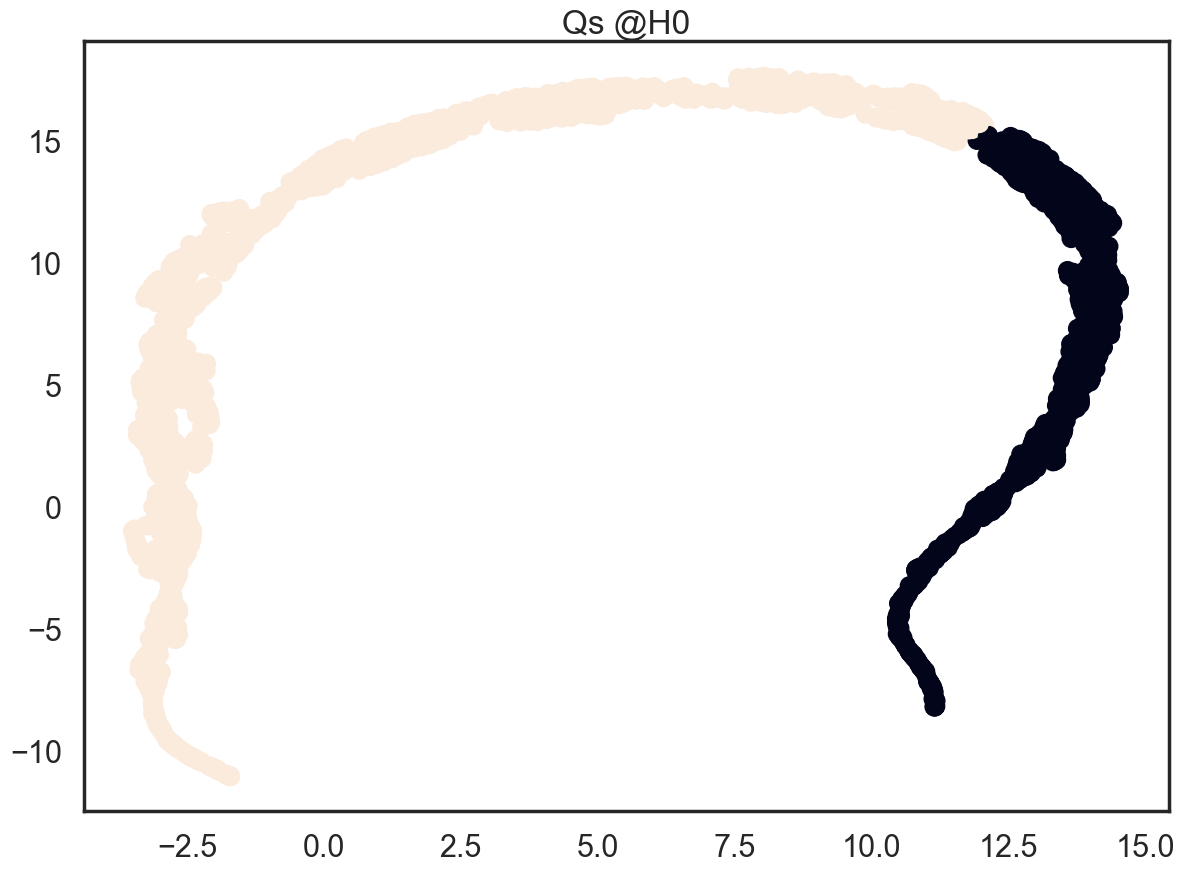

/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


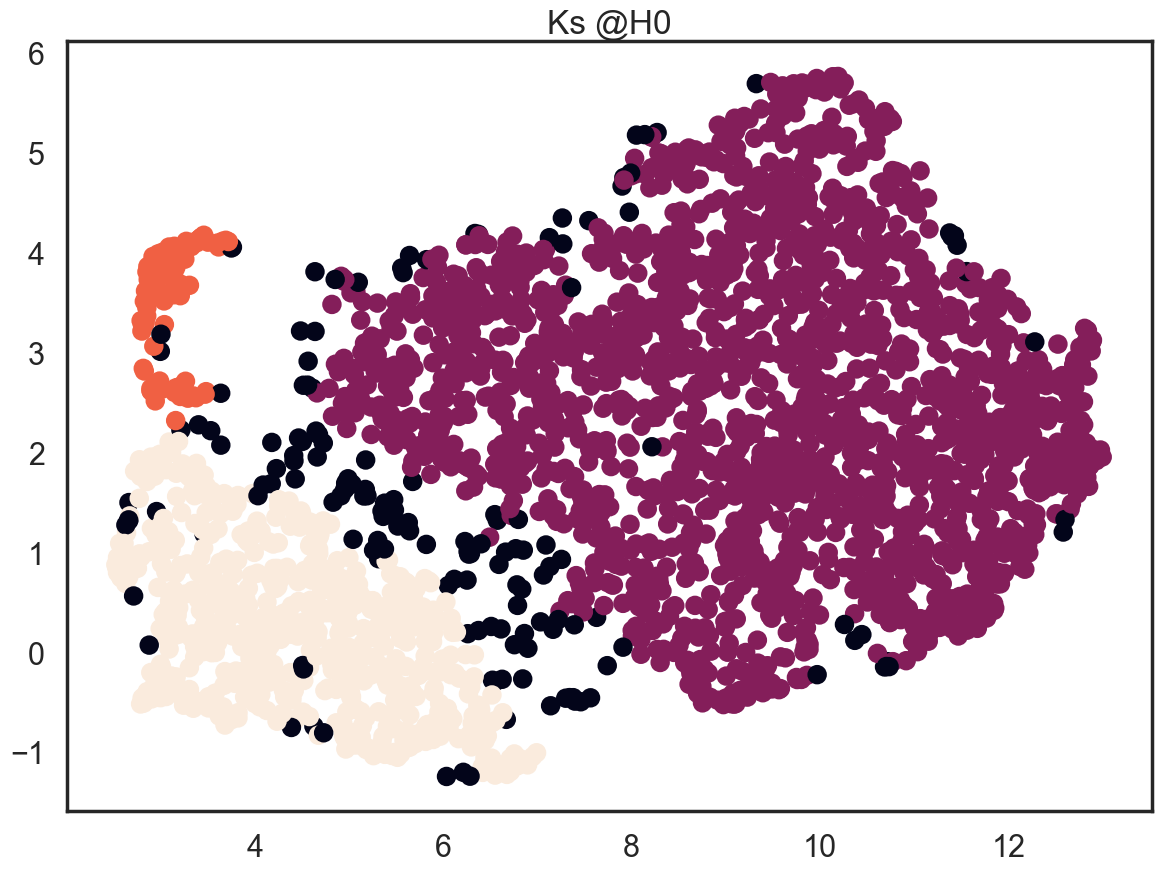

avg link count: 328980, sparsity: 0.036334996340324326


In [43]:
# Use this dataset for GRN inference
grn_full = grn_inferer(model, adata, cell_type="Stem cells")

In [44]:
grn_full.var

,gene_symbol,gene_id-query,uid,symbol,biotype,organism_id,mt,ribo,hb,organism,ensembl_gene_id,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,TFs
ENSG00000000003,TSPAN6,ENSG00000000003,1uTi9dROoaN5,TSPAN6,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000000003,84932,0.718623,0.541523,73.250606,228170.0,12.337851,False,1628.0,0.718623,6.620057,1.064233,23,False
ENSG00000000419,DPM1,ENSG00000000419,4eC1wUNJAO2s,DPM1,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000000419,78585,0.418362,0.349502,75.249598,132834.0,11.796863,False,1228.5,0.418362,1.232587,0.789570,6,False
ENSG00000001036,FUCA2,ENSG00000001036,5kgAeF5qhzAi,FUCA2,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000001036,67405,0.490196,0.398907,78.770747,155642.0,11.955320,False,1946.0,0.490196,3.153400,1.045094,16,False
ENSG00000001626,CFTR,ENSG00000001626,1OL6oMCceGiG,CFTR,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000001626,4913,0.021521,0.021292,98.452647,6833.0,8.829665,False,1655.0,0.021521,0.054033,1.016053,25,False
ENSG00000002549,LAP3,ENSG00000002549,6fLdzqknq0uS,LAP3,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000002549,56091,0.297313,0.260296,82.334100,94400.0,11.455307,False,1880.0,0.297313,0.891136,0.856793,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000284194,SCO2,ENSG00000284194,011rccH0fHP2,SCO2,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000284194,40444,0.220396,0.199176,87.262133,69978.0,11.155950,False,2347.5,0.220396,0.862064,0.906808,10,False
ENSG00000284691,ENSG00000284691,ENSG00000284691,4JTHrGlNI0kS,NaN,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000284691,10199,0.037482,0.036797,96.787818,11901.0,9.384462,False,2870.0,0.037482,0.054206,0.765092,1,False
ENSG00000288701,PRRC2B,ENSG00000288701,68Sg9x3K9vzm,PRRC2B,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000288701,69419,0.374190,0.317864,78.136437,118809.0,11.685281,False,1823.5,0.374190,1.048291,0.820612,4,False
ENSG00000290292,HOMEZ,ENSG00000290292,5J2Cc5IotJQ7,HOMEZ,protein_coding,105,False,False,False,NCBITaxon:9606,ENSG00000290292,15675,0.063088,0.061178,95.063148,20031.0,9.905086,False,2501.0,0.063088,0.110363,0.766490,1,True


In [ ]:
grn_full.write_h5ad("/1_scPRINT/data/grn_sc_fetal.h5ad")